In [1]:
import xml.etree.ElementTree as ET
import pandas as pd

NS = {
    "gpx": "http://www.topografix.com/GPX/1/0"
}

def load_gpx(gpx_file):

    tree = ET.parse(gpx_file)
    root = tree.getroot()

    points = []

    for pt in root.findall(".//gpx:trkpt", NS):

        lat = float(pt.attrib["lat"])
        lon = float(pt.attrib["lon"])

        time_elem = pt.find("gpx:time", NS)

        if time_elem is None:
            continue

        points.append({
            "lat": lat,
            "lon": lon,
            "datetime": pd.to_datetime(time_elem.text)
        })

    return pd.DataFrame(points)

In [2]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):

    R = 6371000

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat/2)**2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon/2)**2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

In [3]:
from geopy.distance import geodesic

def extract_features(df):

    if len(df) < 10:
        return None

    df = df.sort_values("datetime").copy()

    df["dt"] = (
        df["datetime"]
        .diff()
        .dt.total_seconds()
    )

    df["distance_m"] = haversine(
        df["lat"].shift(),
        df["lon"].shift(),
        df["lat"],
        df["lon"]
    )

    df["speed_mps"] = (
        df["distance_m"] / df["dt"]
    )

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    total_distance = df["distance_m"].sum()

    duration = df["dt"].sum()

    mean_speed = df["speed_mps"].median()

    stop_ratio = (
        (df["speed_mps"] < 0.3)
        .mean()
    )

    start = (
        df.iloc[0]["lat"],
        df.iloc[0]["lon"]
    )

    end = (
        df.iloc[-1]["lat"],
        df.iloc[-1]["lon"]
    )

    displacement = geodesic(
        start,
        end
    ).meters

    straightness = (
        displacement / total_distance
        if total_distance > 0
        else np.nan
    )

    return {
        "distance_m": total_distance,
        "duration_s": duration,
        "mean_speed": mean_speed,
        "stop_ratio": stop_ratio,
        "straightness": straightness,
        "n_points": len(df)
    }

In [4]:
import os
from glob import glob

gpx_files = glob(
    r"londres_traces_walking/**/*.gpx",
    recursive=True
)

results = []

for i, file in enumerate(gpx_files):

    try:

        df = load_gpx(file)

        feat = extract_features(df)

        if feat is not None:

            feat["trace_id"] = os.path.basename(file)

            results.append(feat)

    except Exception:
        continue

    if i % 500 == 0:
        print(i)

0


KeyboardInterrupt: 

In [5]:
traj_df = pd.DataFrame(results)

print(traj_df.shape)

traj_df.head()

(8549, 7)


,distance_m,duration_s,mean_speed,stop_ratio,straightness,n_points,trace_id
0,2262.355208,1999.0,1.873450,0.003478,0.001110,575,trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f.gpx
1,546.642905,394.0,1.372672,0.020000,0.806555,50,trace_00064f47-3bf5-44ce-9852-df98d1e86078.gpx
2,3047.193398,2670.0,1.186597,0.021053,0.783338,95,trace_0008688d-e853-4d41-b7bb-3cbf0e9b33af.gpx
3,495.548353,413.0,1.221134,0.000000,0.646184,92,trace_000fa458-e418-447e-9cf2-77200e1ba07e.gpx
4,9334.236875,229.0,18.747260,0.000000,0.205546,1920,trace_0011972f-1a4d-448c-a51b-00c85fb7964b.gpx


In [6]:
traj_df.describe()

,distance_m,duration_s,mean_speed,stop_ratio,straightness,n_points
count,8549.000000,8.549000e+03,8549.000000,8549.000000,8549.000000,8549.000000
mean,1688.678634,1.722879e+05,3.124408,0.069763,0.522407,435.928530
std,3580.165547,7.905559e+06,5.406869,0.097405,0.303230,566.400001
min,13.162682,1.000000e+01,0.000000,0.000000,0.000000,20.000000
25%,544.769409,2.580000e+02,1.212346,0.005698,0.293832,90.000000
50%,1251.299355,8.750000e+02,1.358053,0.031847,0.570033,225.000000
75%,2313.348414,2.177000e+03,1.525375,0.091346,0.787836,541.000000
max,295316.891207,6.193152e+08,35.829112,0.595847,0.998975,5000.000000


In [5]:
import os
import gpxpy
import numpy as np
def load_gpx(filepath):

    tree = ET.parse(filepath)
    root = tree.getroot()

    coords = []

    for pt in root.findall(".//gpx:trkpt", NS):

        lat = float(pt.attrib["lat"])
        lon = float(pt.attrib["lon"])

        coords.append((lat, lon))

    return np.array(coords)


def load_gpx_time(gpx_file):

    tree = ET.parse(gpx_file)
    root = tree.getroot()

    points = []

    for pt in root.findall(".//gpx:trkpt", NS):

        lat = float(pt.attrib["lat"])
        lon = float(pt.attrib["lon"])

        time_elem = pt.find("gpx:time", NS)

        if time_elem is None:
            continue

        points.append({
            "lat": lat,
            "lon": lon,
            "datetime": pd.to_datetime(time_elem.text)
        })

    return np.array(points)

In [6]:
from dtaidistance import dtw
def trajectory_dtw(traj1, traj2):

    lat_dist = dtw.distance(
        traj1[:,0],
        traj2[:,0]
    )

    lon_dist = dtw.distance(
        traj1[:,1],
        traj2[:,1]
    )

    return np.sqrt(
        lat_dist**2 +
        lon_dist**2
    )

In [12]:
from shapely.geometry import LineString
import numpy as np

def simplify_trajectory(traj, tolerance=0.0001):
    """
    traj: numpy array (n,2) [lat, lon]

    tolerance:
        0.0001 ≈ 10 m
        0.0002 ≈ 20 m
        0.0005 ≈ 50 m
    """

    if len(traj) < 3:
        return traj

    line = LineString(
        [(lon, lat) for lat, lon in traj]
    )

    simplified = line.simplify(
        tolerance=tolerance,
        preserve_topology=False
    )

    coords = np.array(
        [(lat, lon)
         for lon, lat in simplified.coords]
    )

    return coords

In [24]:
GPX_FOLDER = "londres_traces_walking"

trajectories = []
lengths_before = []
lengths_after = []

for file in os.listdir(GPX_FOLDER):

    if not file.endswith(".gpx"):
        continue

    try:

        traj = load_gpx(
            os.path.join(GPX_FOLDER, file)
        )

        if len(traj) < 20:
            continue

        traj_simple = simplify_trajectory(
            traj,
            tolerance=0.0002
        )

        trajectories.append(traj_simple)

        lengths_before.append(len(traj))
        lengths_after.append(len(traj_simple))

    except Exception:
        continue

print(f"Trajectories loaded: {len(trajectories):,}")

print(
    f"Mean points before: "
    f"{np.mean(lengths_before):.1f}"
)

print(
    f"Mean points after: "
    f"{np.mean(lengths_after):.1f}"
)

print(
    f"Compression ratio: "
    f"{np.mean(lengths_after)/np.mean(lengths_before):.2f}"
)

Trajectories loaded: 8,549
Mean points before: 435.9
Mean points after: 9.9
Compression ratio: 0.02


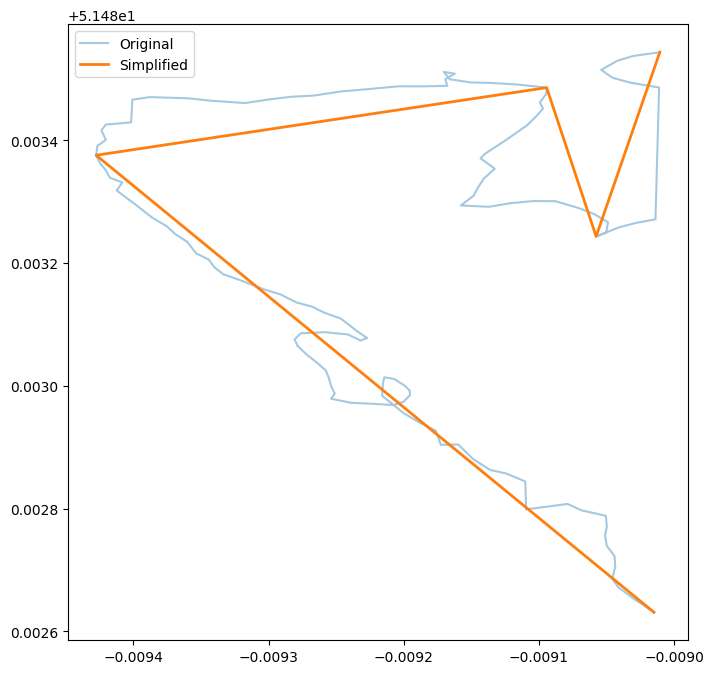

In [25]:
import matplotlib.pyplot as plt

traj = load_gpx(
    os.path.join(
        GPX_FOLDER,
        os.listdir(GPX_FOLDER)[20]
    )
)

traj_simple = simplify_trajectory(
    traj,
    tolerance=0.0002
)

plt.figure(figsize=(8,8))

plt.plot(
    traj[:,1],
    traj[:,0],
    alpha=0.4,
    label="Original"
)

plt.plot(
    traj_simple[:,1],
    traj_simple[:,0],
    linewidth=2,
    label="Simplified"
)

plt.legend()
plt.show()

In [26]:
from tqdm import tqdm

n = len(trajectories)

D = np.zeros((n,n))

for i in tqdm(range(n)):

    for j in range(i+1,n):

        d = trajectory_dtw(
            trajectories[i],
            trajectories[j]
        )

        D[i,j] = d
        D[j,i] = d

100%|██████████| 8549/8549 [2:05:04<00:00,  1.14it/s]  


In [27]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    metric="precomputed",
    eps=0.01,
    min_samples=5
)

labels = db.fit_predict(D)

In [28]:
pd.Series(labels).value_counts()

-1      4448
 10      473
 6       289
 2       234
 7       209
        ... 
 221       5
 193       4
 145       4
 228       4
 218       3
Name: count, Length: 235, dtype: int64

C:\Users\oussama.nair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\oussama.nair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\oussama.nair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


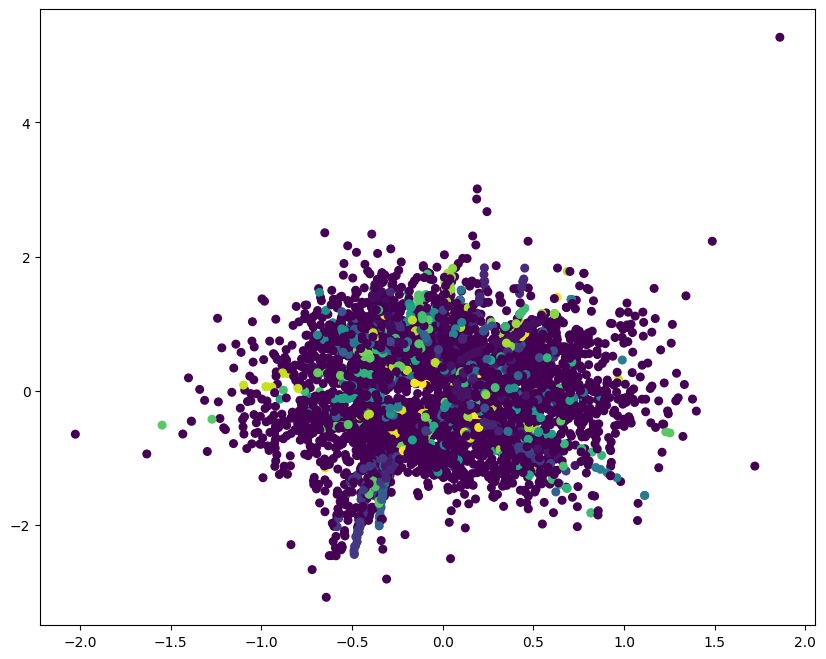

In [29]:
from sklearn.manifold import MDS

emb = MDS(
    dissimilarity="precomputed",
    random_state=42
)

X = emb.fit_transform(D)
plt.figure(figsize=(10,8))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    s=30
) 

plt.show()

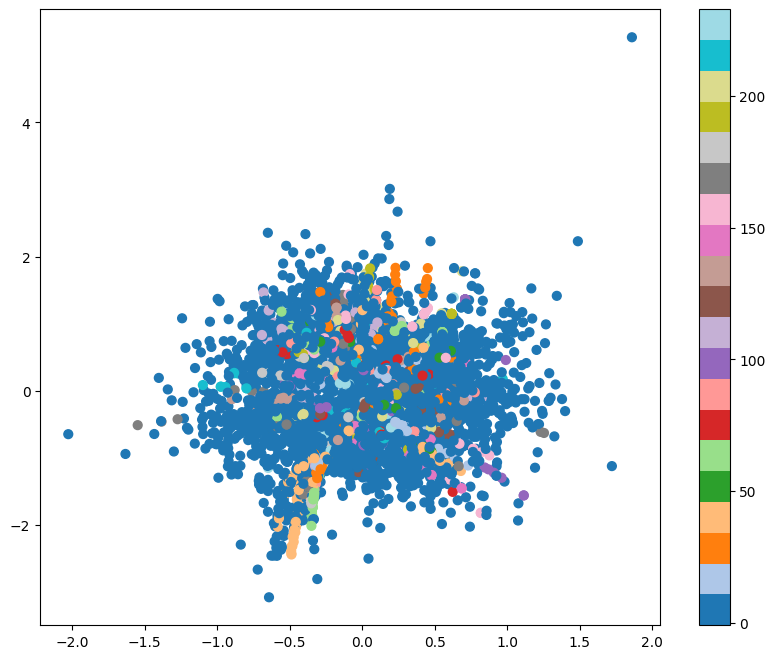

In [31]:
plt.figure(figsize=(10,8))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap="tab20",
    s=40
)

plt.colorbar()
plt.show()

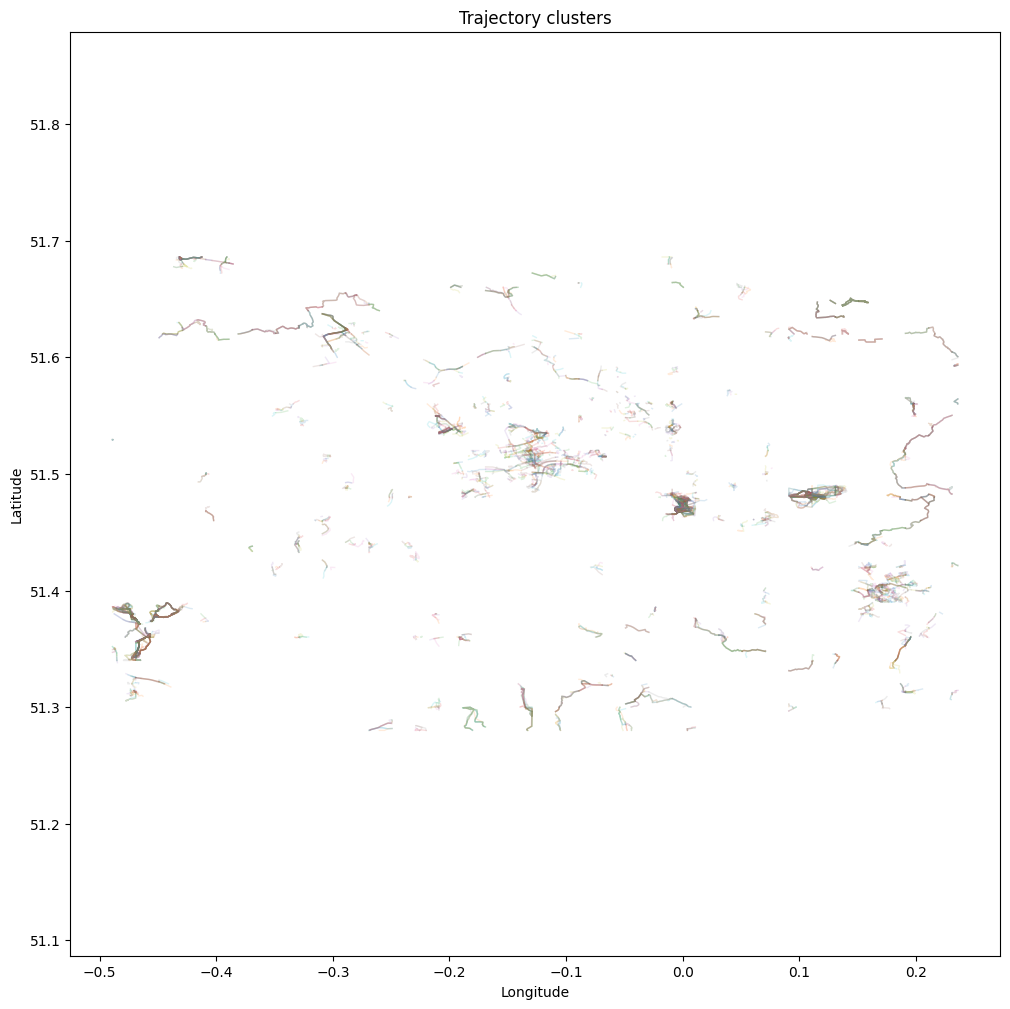

In [32]:
import matplotlib.pyplot as plt
import numpy as np

unique_clusters = np.unique(labels)

plt.figure(figsize=(12,12))

for cluster_id in unique_clusters:

    if cluster_id == -1:
        continue

    idxs = np.where(labels == cluster_id)[0]

    for idx in idxs:

        traj = trajectories[idx]

        plt.plot(
            traj[:,1],   # lon
            traj[:,0],   # lat
            alpha=0.15,
            linewidth=1
        )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory clusters")
plt.axis("equal")
plt.show()

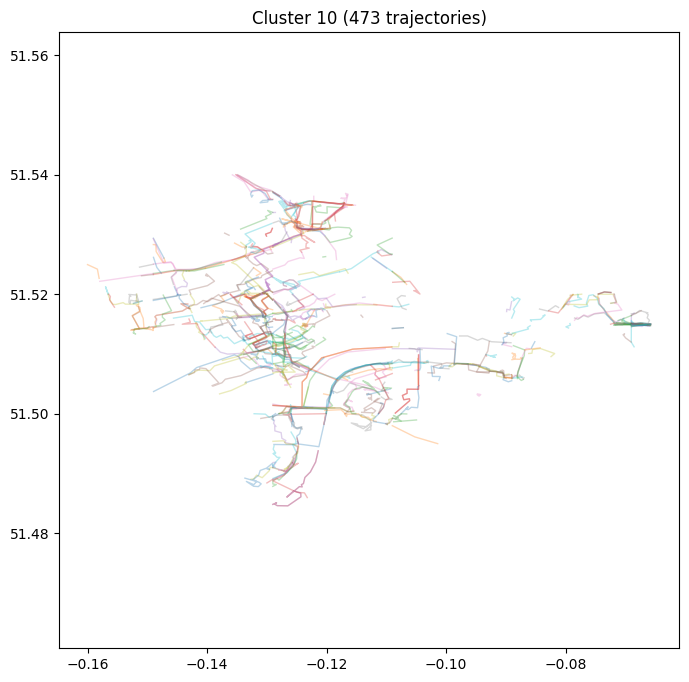

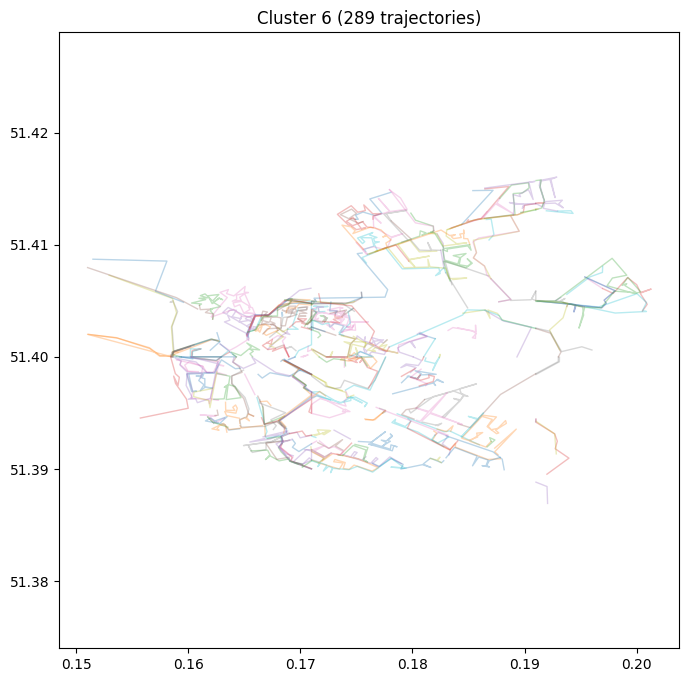

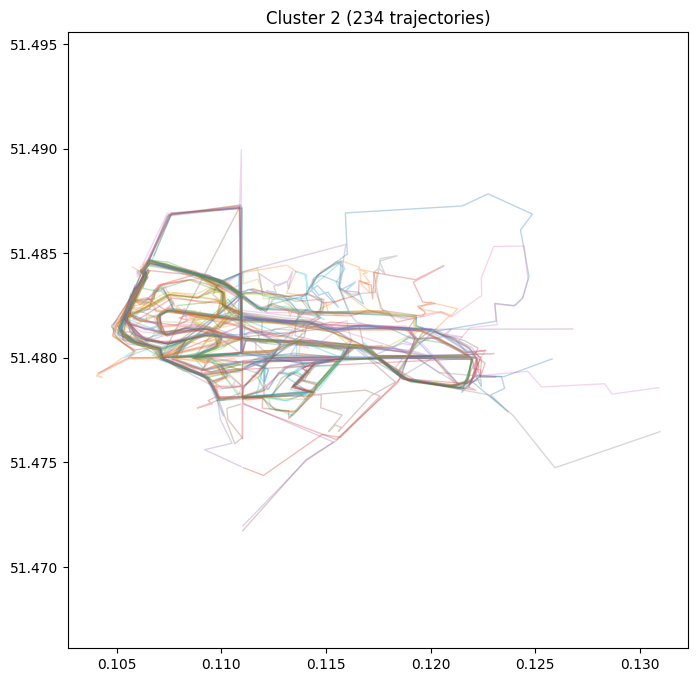

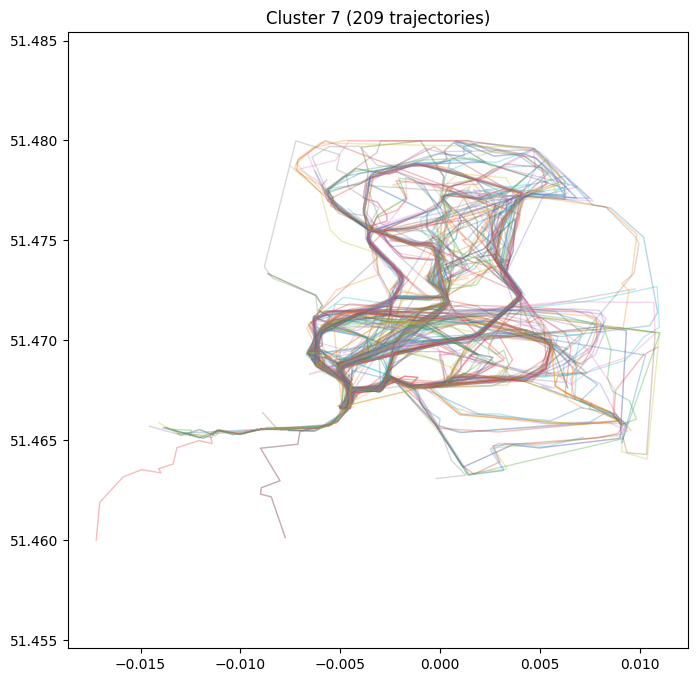

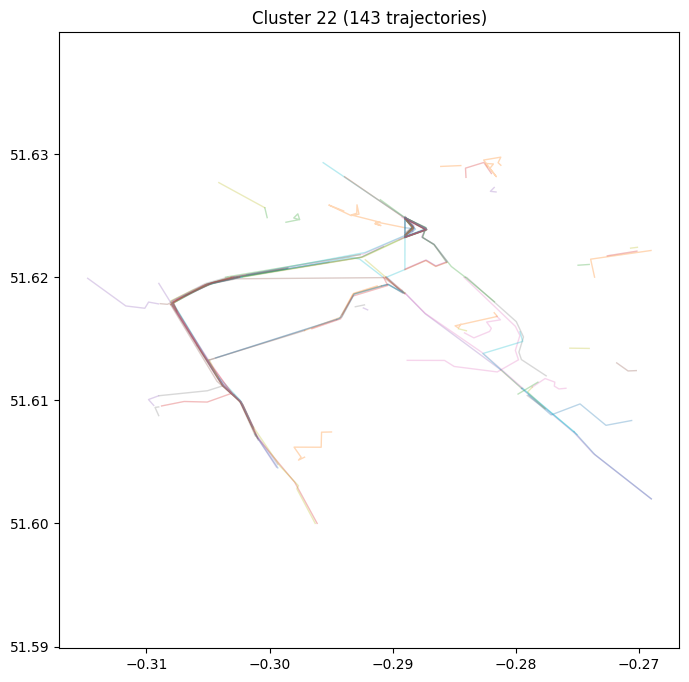

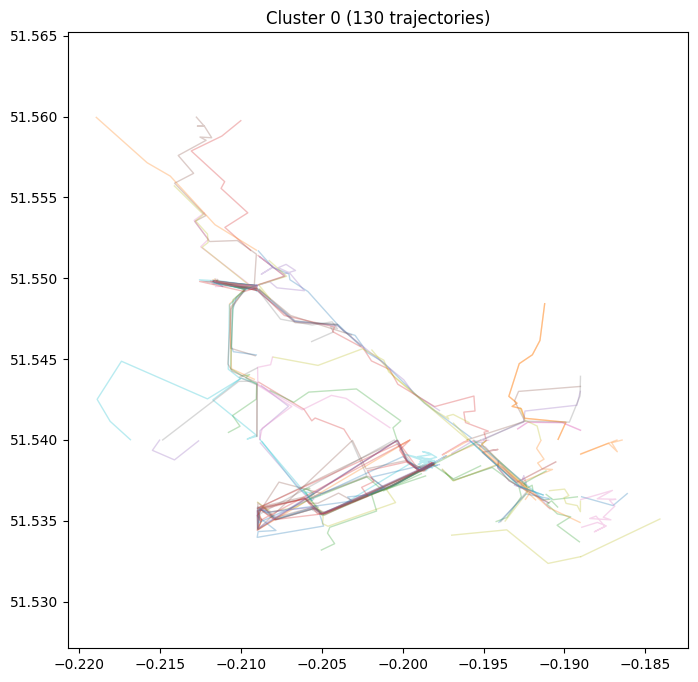

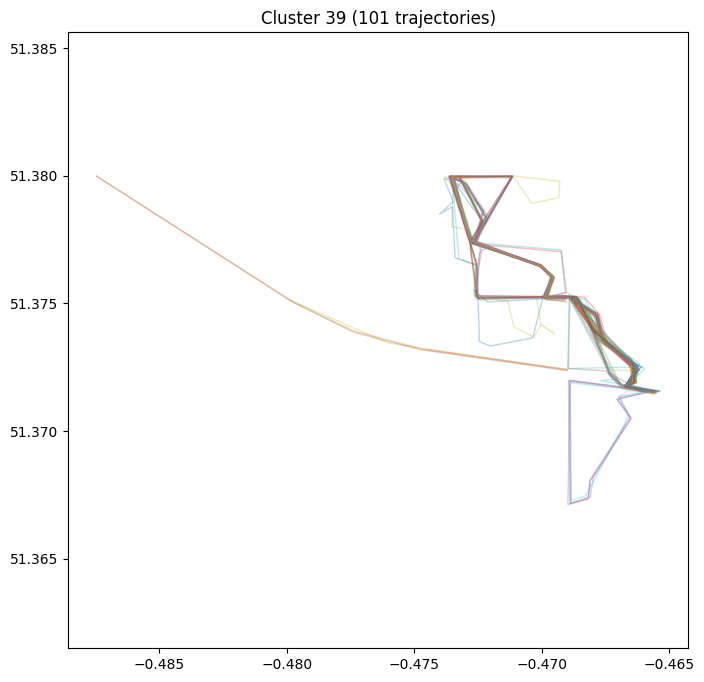

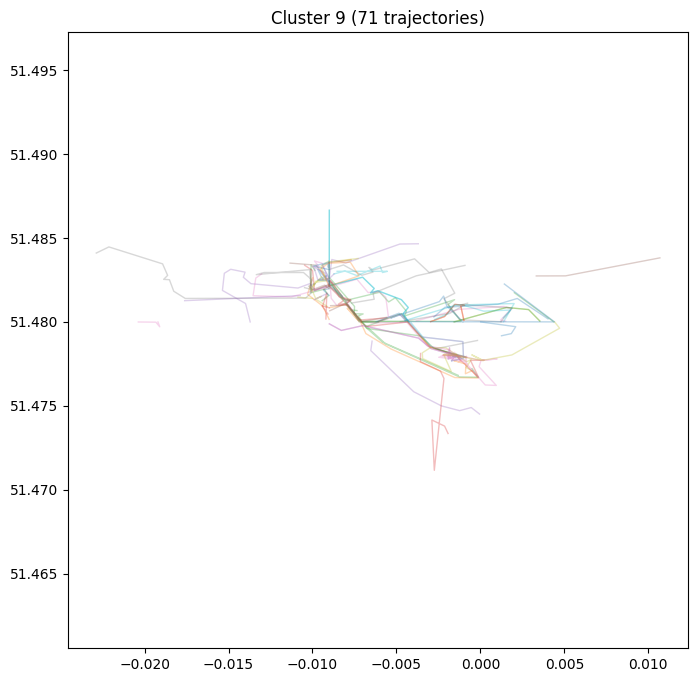

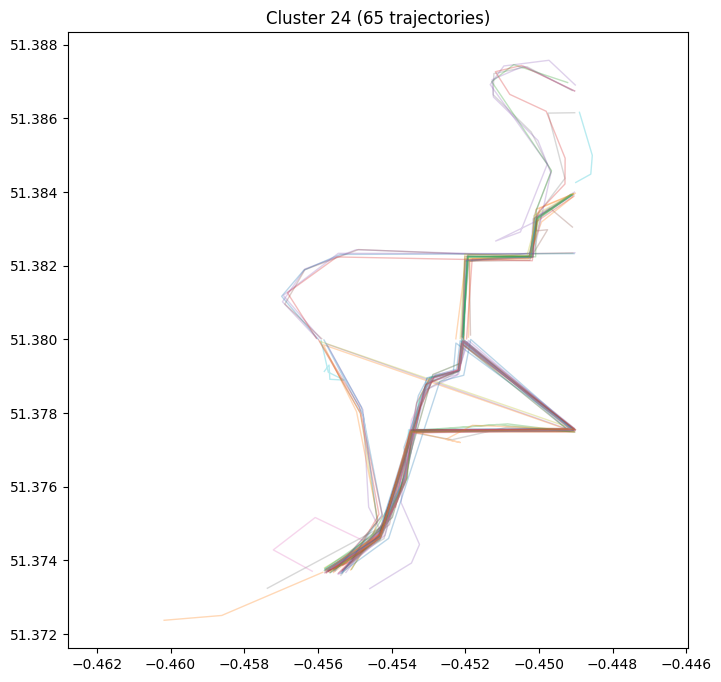

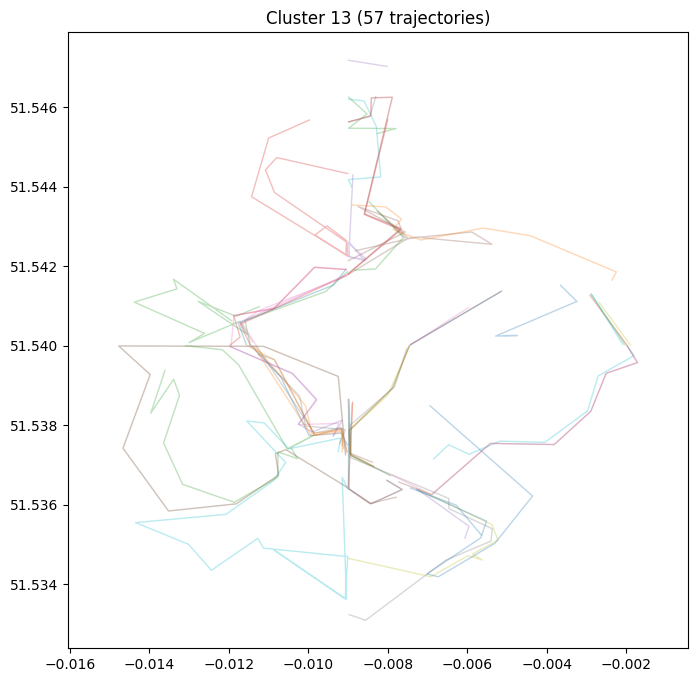

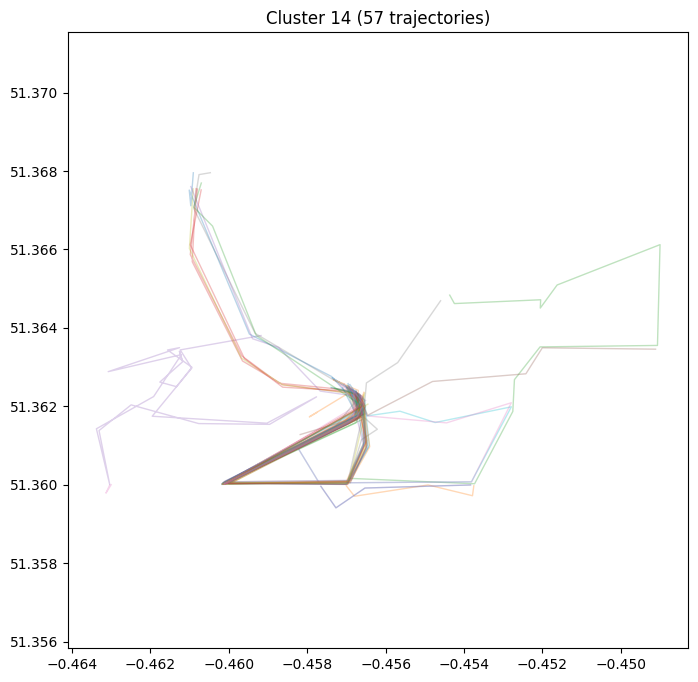

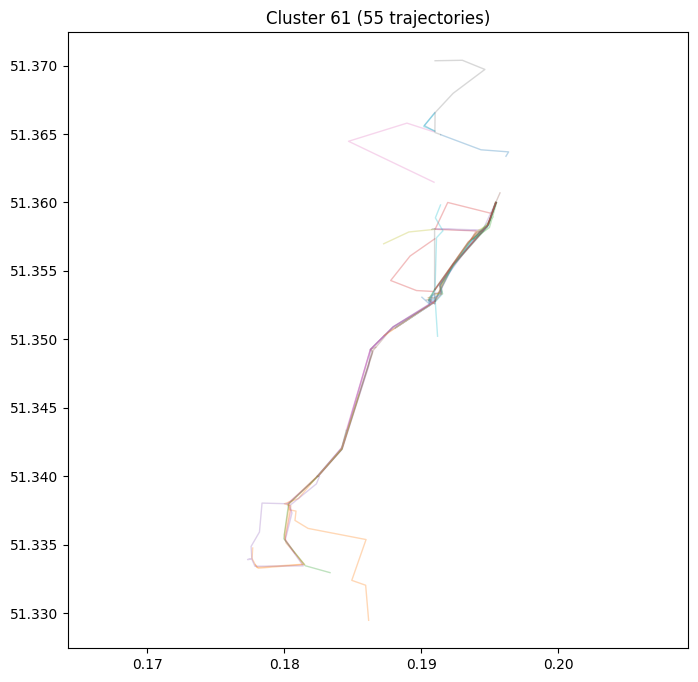

In [33]:
top_clusters = (
    pd.Series(labels)
    .value_counts()
    .drop(-1, errors="ignore")
    .head(12)
    .index
)

for cluster_id in top_clusters:

    plt.figure(figsize=(8,8))

    idxs = np.where(labels == cluster_id)[0]

    for idx in idxs:

        traj = trajectories[idx]

        plt.plot(
            traj[:,1],
            traj[:,0],
            alpha=0.3,
            linewidth=1
        )

    plt.title(
        f"Cluster {cluster_id} ({len(idxs)} trajectories)"
    )

    plt.axis("equal")
    plt.show()

In [34]:
from geopy.distance import geodesic
import numpy as np

def speed_profile(traj):

    if len(traj) < 3:
        return None

    dist = [0]
    speed = []

    for i in range(1, len(traj)):

        p1 = (traj[i-1,0], traj[i-1,1])
        p2 = (traj[i,0], traj[i,1])

        d = geodesic(p1, p2).meters
        dist.append(dist[-1] + d)

        if traj.shape[1] >= 3:

            dt = (
                traj[i,2] -
                traj[i-1,2]
            ).total_seconds()

            if dt > 0:
                speed.append(d/dt)
            else:
                speed.append(np.nan)

        else:
            speed.append(np.nan)

    dist = np.array(dist[1:])
    speed = np.array(speed)

    if dist[-1] < 100:
        return None

    dist_norm = dist / dist[-1]

    return dist_norm, speed

In [41]:
raw_trajectories = []

for file in os.listdir(GPX_FOLDER):

    if not file.endswith(".gpx"):
        continue

    try:

        traj = load_gpx_time(
            os.path.join(GPX_FOLDER, file)
        )

        if len(traj) < 20:
            continue

        raw_trajectories.append(traj)

    except:
        pass

In [42]:
print(len(raw_trajectories))
print(len(trajectories))
print(len(labels))

8549
8549
8549


In [46]:
from geopy.distance import geodesic
import numpy as np
import pandas as pd

rows = []

for traj, cluster in zip(raw_trajectories, labels):

    if cluster == -1:
        continue

    speeds = []

    for i in range(1, len(traj)):

        p1 = traj[i-1]
        p2 = traj[i]

        d = geodesic(
            (p1["lat"], p1["lon"]),
            (p2["lat"], p2["lon"])
        ).meters

        dt = (
            p2["datetime"] -
            p1["datetime"]
        ).total_seconds()

        if dt <= 0:
            continue

        v = d / dt

        # filtre marche
        if 0 < v < 3:
            speeds.append(v)

    if len(speeds) == 0:
        continue

    rows.append({
        "cluster": cluster,
        "mean_speed": np.mean(speeds),
        "std_speed": np.std(speeds),
        "n_points": len(traj)
    })

speed_df = pd.DataFrame(rows)

print(speed_df.head())

   cluster  mean_speed  std_speed  n_points
0        0    1.953657   0.529134       575
1        1    1.149614   0.291920        95
2        2    1.220288   0.187836        92
3        3    1.523040   0.549500      1920
4        4    0.934042   0.670241        71


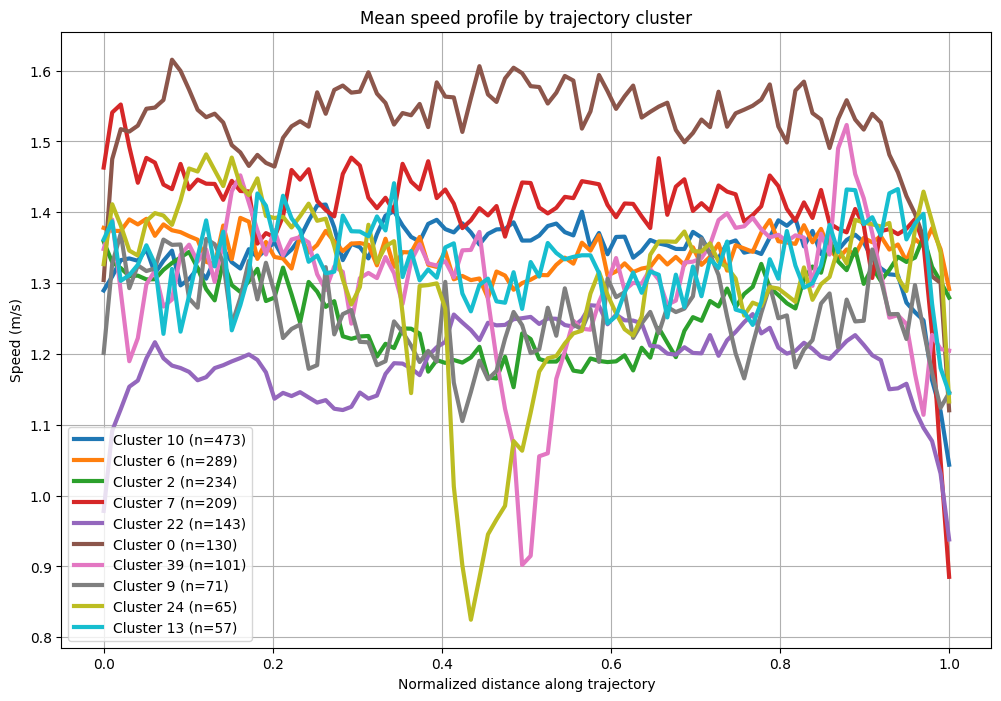

In [48]:
from geopy.distance import geodesic
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Top 10 clusters (hors bruit DBSCAN = -1)
top_clusters = [
    c for c, _ in
    Counter(labels[labels != -1]).most_common(10)
]

grid = np.linspace(0, 1, 100)

plt.figure(figsize=(12,8))

for cluster_id in top_clusters:

    profiles = []

    idxs = np.where(labels == cluster_id)[0]

    for idx in idxs:

        traj = raw_trajectories[idx]

        if len(traj) < 20:
            continue

        speeds = []
        cumdist = [0]

        for i in range(1, len(traj)):

            p1 = traj[i-1]
            p2 = traj[i]

            d = geodesic(
                (p1["lat"], p1["lon"]),
                (p2["lat"], p2["lon"])
            ).meters

            dt = (
                p2["datetime"]
                - p1["datetime"]
            ).total_seconds()

            if dt <= 0:
                continue

            v = d / dt

            # filtre marche
            if v > 3:
                continue

            speeds.append(v)

            cumdist.append(
                cumdist[-1] + d
            )

        if len(speeds) < 10:
            continue

        cumdist = np.array(cumdist[:-1])

        if cumdist[-1] == 0:
            continue

        norm_dist = cumdist / cumdist[-1]

        profile = np.interp(
            grid,
            norm_dist,
            speeds
        )

        profiles.append(profile)

    if len(profiles) == 0:
        continue

    profiles = np.vstack(profiles)

    mean_profile = np.nanmean(
        profiles,
        axis=0
    )

    plt.plot(
        grid,
        mean_profile,
        linewidth=3,
        label=f"Cluster {cluster_id} (n={len(profiles)})"
    )

plt.xlabel("Normalized distance along trajectory")
plt.ylabel("Speed (m/s)")
plt.title("Mean speed profile by trajectory cluster")
plt.legend()
plt.grid(True)
plt.show()

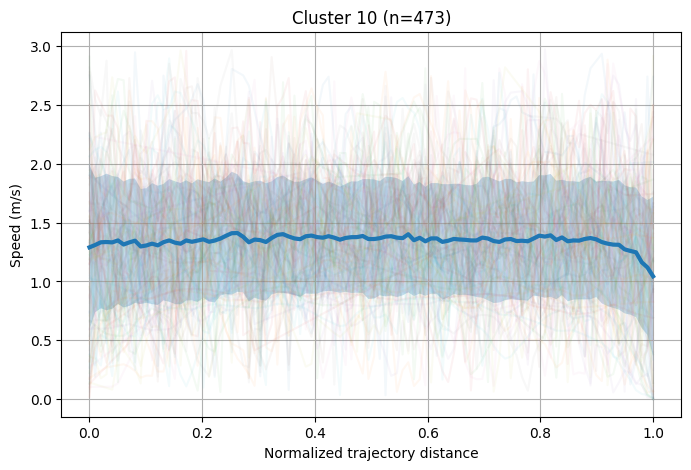

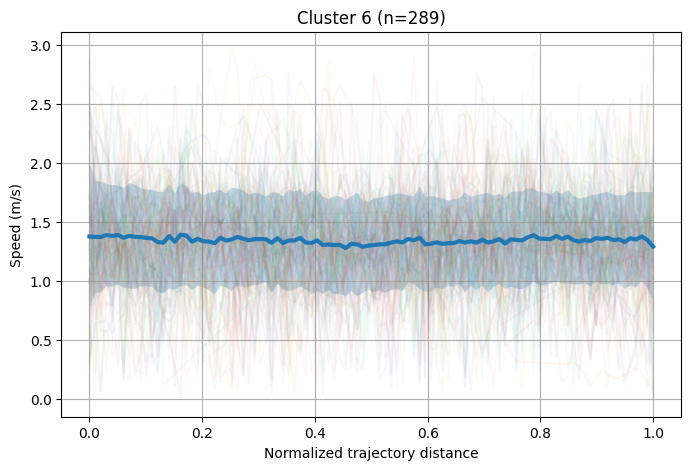

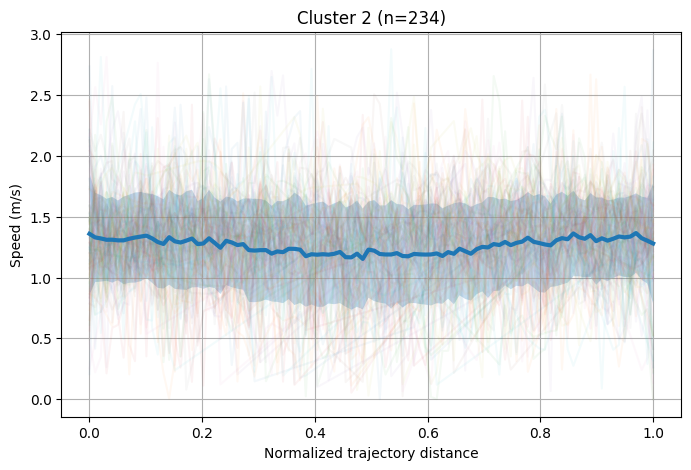

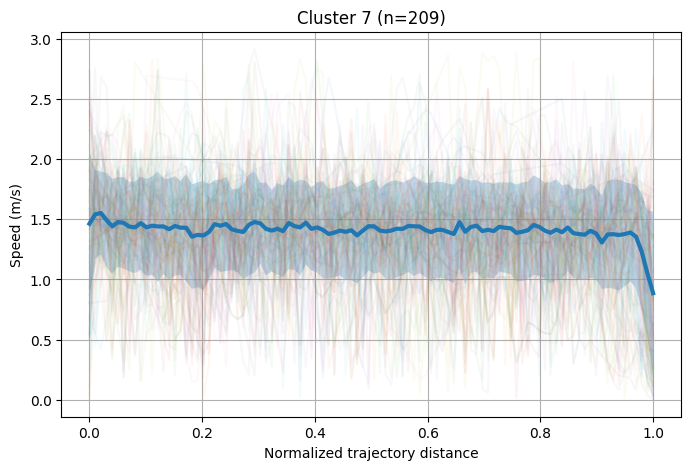

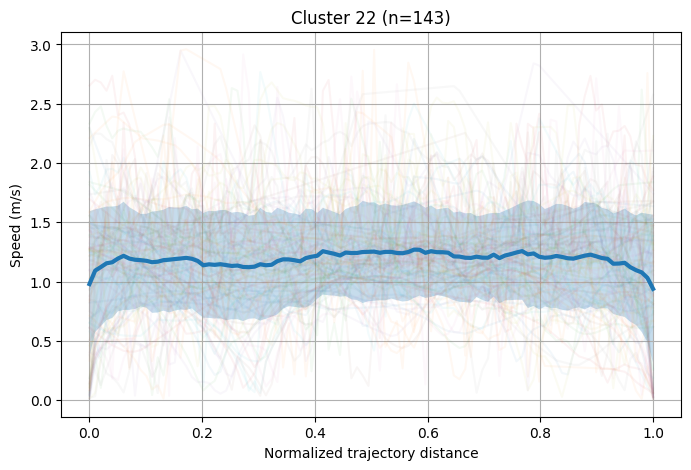

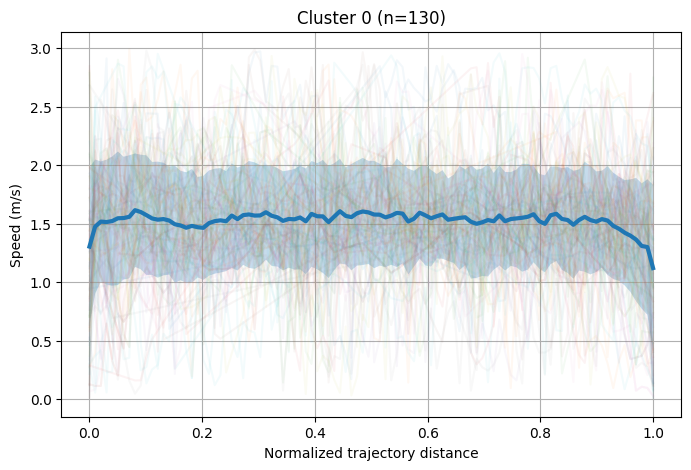

In [49]:
from collections import Counter
from geopy.distance import geodesic
import numpy as np
import matplotlib.pyplot as plt

top_clusters = [
    c for c,_ in
    Counter(labels[labels!=-1]).most_common(6)
]

grid = np.linspace(0, 1, 100)

for cluster_id in top_clusters:

    idxs = np.where(labels == cluster_id)[0]

    profiles = []

    for idx in idxs:

        traj = raw_trajectories[idx]

        speeds = []
        cumdist = [0]

        for i in range(1, len(traj)):

            p1 = traj[i-1]
            p2 = traj[i]

            d = geodesic(
                (p1["lat"], p1["lon"]),
                (p2["lat"], p2["lon"])
            ).meters

            dt = (
                p2["datetime"]
                - p1["datetime"]
            ).total_seconds()

            if dt <= 0:
                continue

            v = d / dt

            if v > 3:
                continue

            speeds.append(v)

            cumdist.append(
                cumdist[-1] + d
            )

        if len(speeds) < 10:
            continue

        cumdist = np.array(cumdist[:-1])

        if cumdist[-1] == 0:
            continue

        norm_dist = cumdist / cumdist[-1]

        profile = np.interp(
            grid,
            norm_dist,
            speeds
        )

        profiles.append(profile)

    if len(profiles) < 5:
        continue

    profiles = np.vstack(profiles)

    mean_profile = np.mean(
        profiles,
        axis=0
    )

    std_profile = np.std(
        profiles,
        axis=0
    )

    plt.figure(figsize=(8,5))

    # profils individuels
    for p in profiles[:100]:
        plt.plot(
            grid,
            p,
            alpha=0.05
        )

    # moyenne
    plt.plot(
        grid,
        mean_profile,
        linewidth=3,
        label="Mean profile"
    )

    plt.fill_between(
        grid,
        mean_profile - std_profile,
        mean_profile + std_profile,
        alpha=0.25
    )

    plt.title(
        f"Cluster {cluster_id} (n={len(profiles)})"
    )

    plt.xlabel(
        "Normalized trajectory distance"
    )

    plt.ylabel(
        "Speed (m/s)"
    )

    plt.grid(True)

    plt.show()

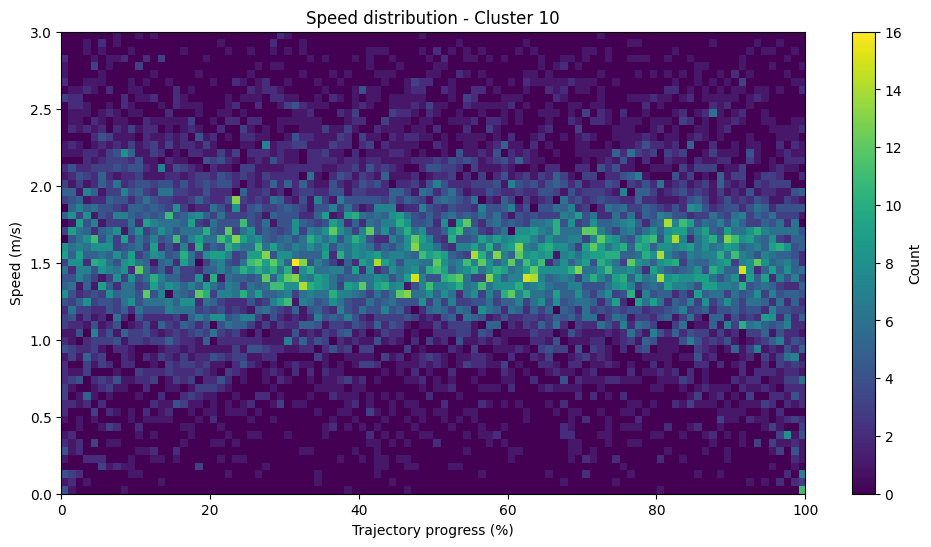

In [ ]:
profiles = np.vstack(profiles)

speed_bins = np.linspace(
    0,
    3,
    60
)

heat = np.zeros(
    (
        len(speed_bins)-1,
        profiles.shape[1]
    )
)

for j in range(profiles.shape[1]):

    hist, _ = np.histogram(
        profiles[:, j],
        bins=speed_bins
    )

    heat[:, j] = hist

plt.figure(figsize=(12,6))

plt.imshow(
    heat,
    aspect="auto",
    origin="lower",
    extent=[0,100,0,3]
)

plt.colorbar(label="Count")

plt.xlabel(
    "Trajectory progress (%)"
)

plt.ylabel(
    "Speed (m/s)"
)

plt.title(
    f"Speed distribution - Cluster { }"
)

plt.show()

Cluster 10


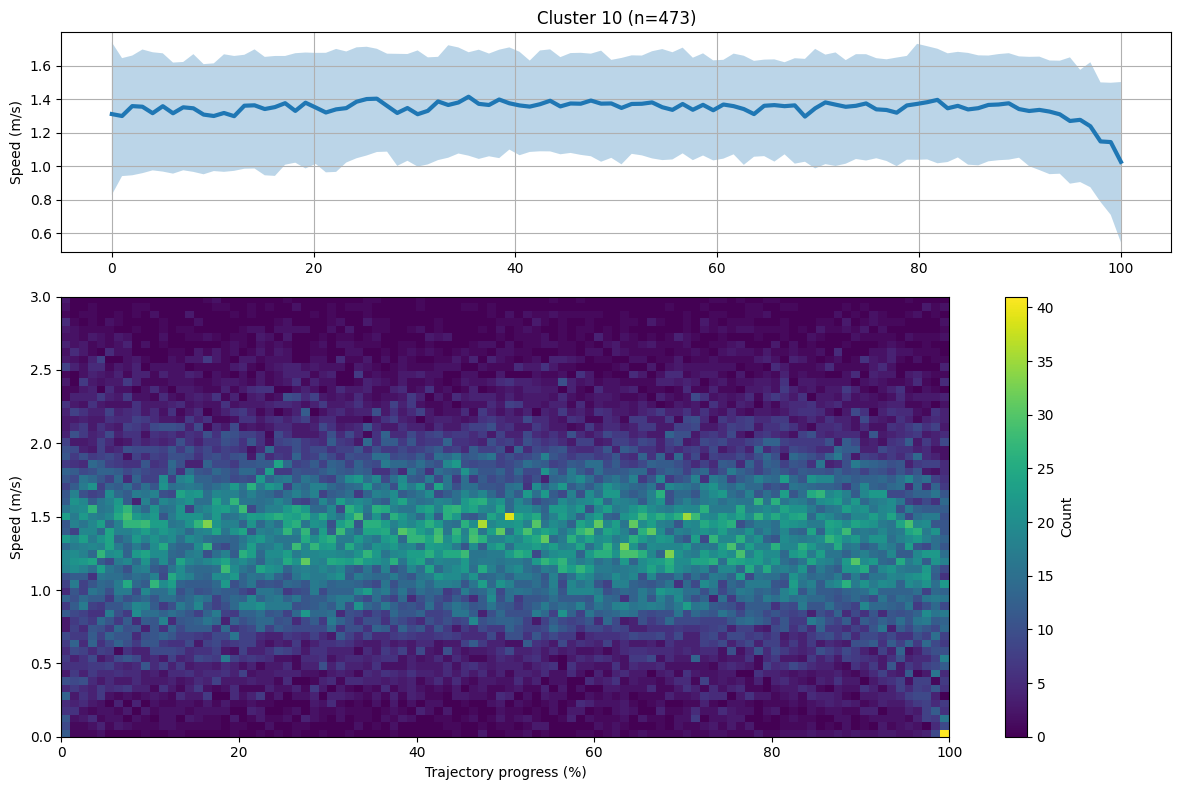

Cluster 6


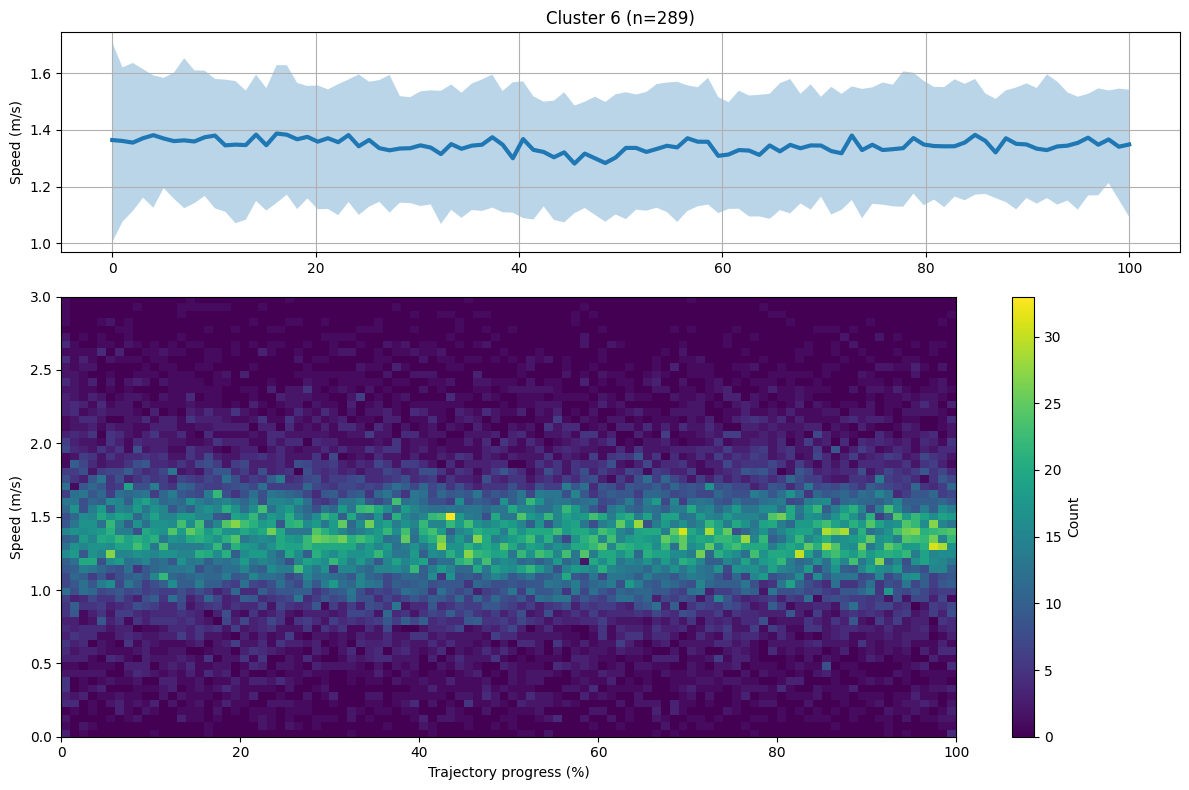

Cluster 2


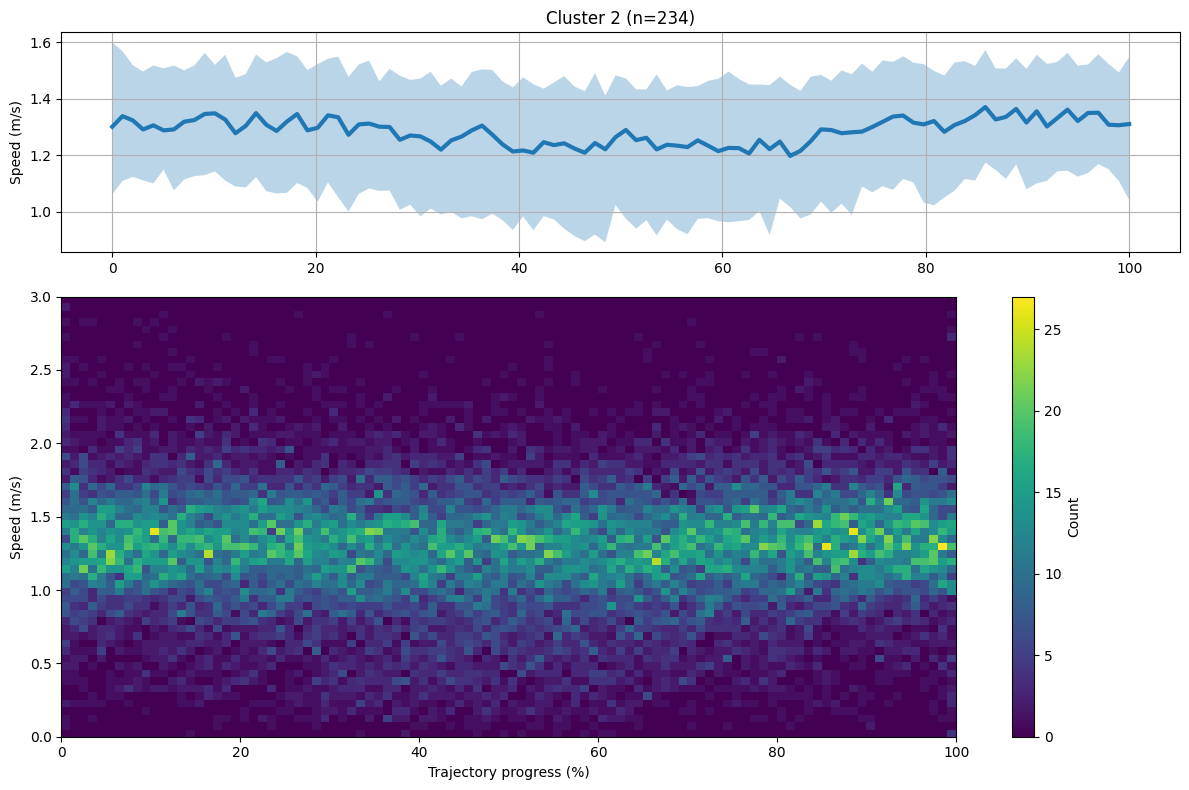

Cluster 7


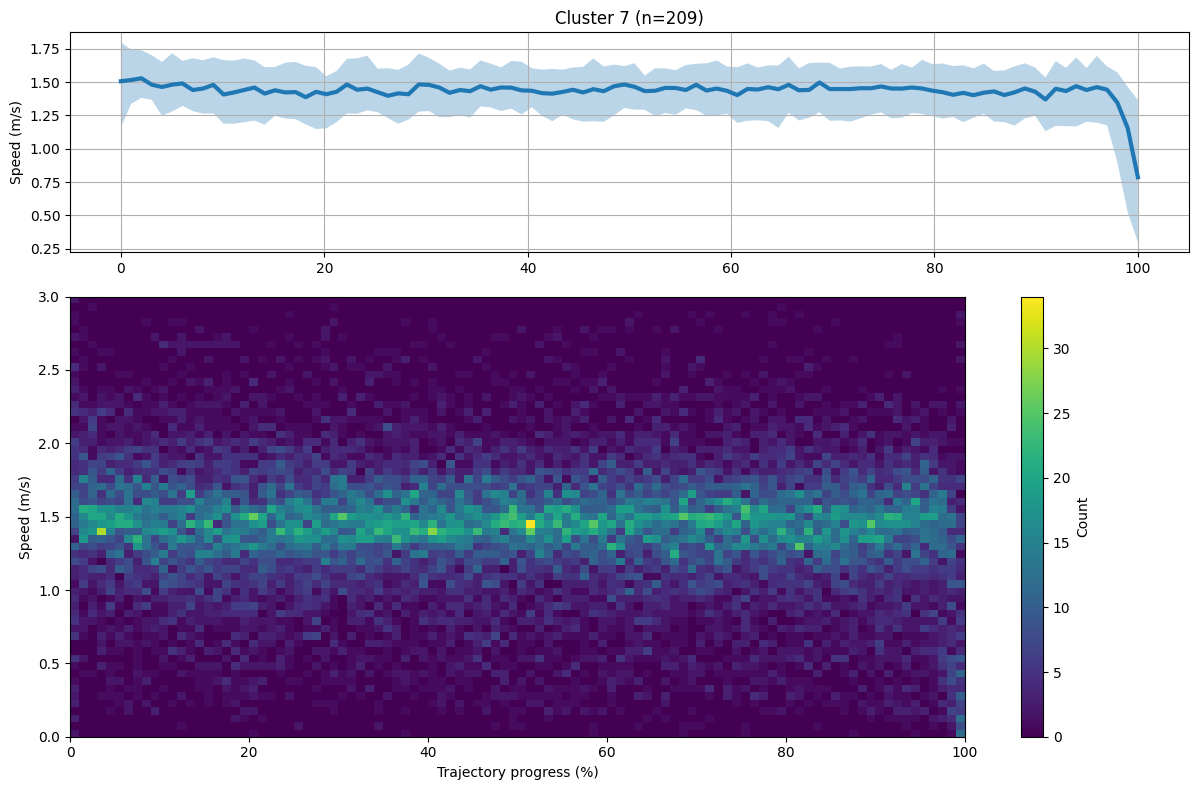

Cluster 22


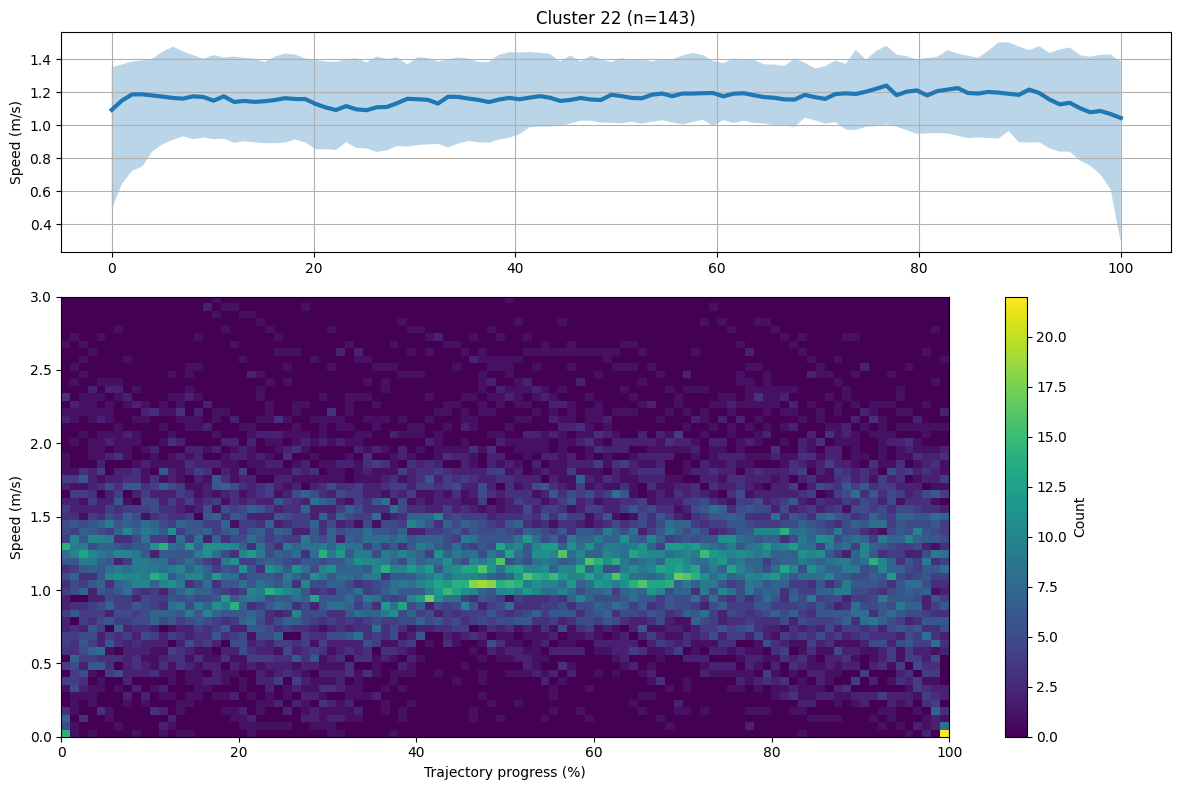

Cluster 0


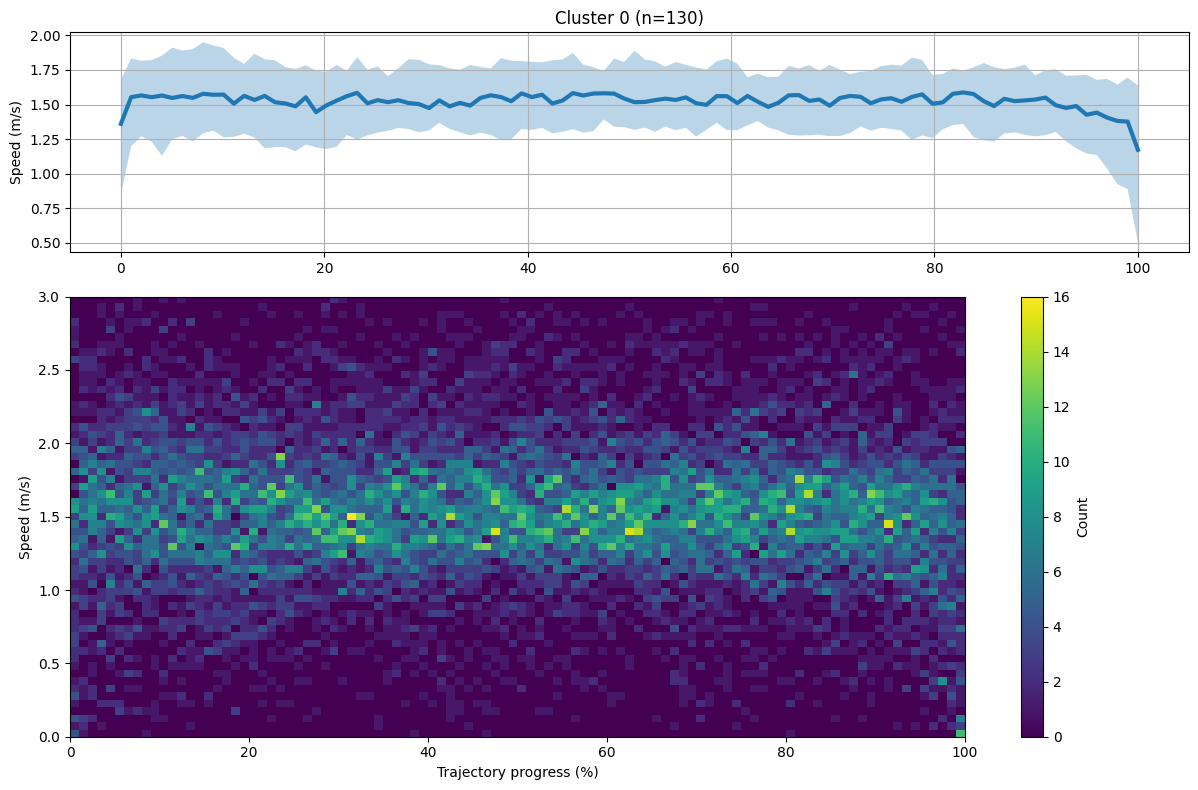

In [57]:
from collections import Counter
from geopy.distance import geodesic
import numpy as np
import matplotlib.pyplot as plt

top_clusters = [
    c for c,_ in
    Counter(labels[labels!=-1]).most_common(6)
]

grid = np.linspace(0, 1, 100)

for cluster_id in top_clusters:

    print(f"Cluster {cluster_id}")

    idxs = np.where(labels == cluster_id)[0]

    profiles = []

    for idx in idxs:

        traj = raw_trajectories[idx]

        speeds = []
        cumdist = [0]

        for i in range(1, len(traj)):

            p1 = traj[i-1]
            p2 = traj[i]

            d = geodesic(
                (p1["lat"], p1["lon"]),
                (p2["lat"], p2["lon"])
            ).meters

            dt = (
                p2["datetime"]
                - p1["datetime"]
            ).total_seconds()

            if dt <= 0:
                continue

            v = d / dt

            # walking filter
            if v > 3:
                continue

            speeds.append(v)

            cumdist.append(
                cumdist[-1] + d
            )

        if len(speeds) < 10:
            continue

        cumdist = np.array(cumdist[:-1])

        if cumdist[-1] == 0:
            continue

        norm_dist = cumdist / cumdist[-1]

        profile = np.interp(
            grid,
            norm_dist,
            speeds
        )

        profiles.append(profile)

    if len(profiles) < 5:
        continue

    profiles = np.vstack(profiles)

    # ==================================================
    # Median profile
    # ==================================================

    median = np.nanmedian(
        profiles,
        axis=0
    )

    q25 = np.nanpercentile(
        profiles,
        25,
        axis=0
    )

    q75 = np.nanpercentile(
        profiles,
        75,
        axis=0
    )

    # ==================================================
    # Heatmap
    # ==================================================

    speed_bins = np.linspace(
        0,
        3,
        60
    )

    heat = np.zeros(
        (
            len(speed_bins)-1,
            len(grid)
        )
    )

    for j in range(len(grid)):

        hist, _ = np.histogram(
            profiles[:,j],
            bins=speed_bins
        )

        heat[:,j] = hist

    # ==================================================
    # Plot
    # ==================================================

    fig, ax = plt.subplots(
        2,
        1,
        figsize=(12,8),
        gridspec_kw={
            "height_ratios":[1,2]
        }
    )

    # ---------- top ----------

    ax[0].plot(
        grid*100,
        median,
        linewidth=3
    )

    ax[0].fill_between(
        grid*100,
        q25,
        q75,
        alpha=0.3
    )

    ax[0].set_ylabel(
        "Speed (m/s)"
    )

    ax[0].set_title(
        f"Cluster {cluster_id} (n={len(profiles)})"
    )

    ax[0].grid(True)

    # ---------- bottom ----------

    im = ax[1].imshow(
        heat,
        aspect="auto",
        origin="lower",
        extent=[
            0,
            100,
            speed_bins[0],
            speed_bins[-1]
        ]
    )

    ax[1].set_xlabel(
        "Trajectory progress (%)"
    )

    ax[1].set_ylabel(
        "Speed (m/s)"
    )

    cbar = plt.colorbar(
        im,
        ax=ax[1]
    )

    cbar.set_label(
        "Count"
    )

    plt.tight_layout()

    plt.show()

In [58]:
from astral import LocationInfo
from astral.sun import sun
import pandas as pd

city = LocationInfo(
    "London",
    "UK",
    "Europe/London",
    51.5074,
    -0.1278
)

def get_period(dt):

    local_dt = dt.tz_convert("Europe/London")

    s = sun(
        city.observer,
        date=local_dt.date(),
        tzinfo="Europe/London"
    )

    dawn = s["dawn"]      # nautical dawn
    dusk = s["dusk"]      # nautical dusk

    if local_dt < dawn:
        return "night"

    elif local_dt > dusk:
        return "night"

    else:
        return "day"

In [59]:
def trajectory_period(traj):

    start = traj[0]["datetime"]
    end = traj[-1]["datetime"]

    p1 = get_period(start)
    p2 = get_period(end)

    if p1 == "day" and p2 == "day":
        return "day"

    elif p1 == "night" and p2 == "night":
        return "night"

    else:
        return "mixed"

In [60]:
from collections import Counter

for cluster_id in top_clusters:

    idxs = np.where(labels == cluster_id)[0]

    periods = []

    for idx in idxs:

        traj = raw_trajectories[idx]

        periods.append(
            trajectory_period(traj)
        )

    print(
        f"\nCluster {cluster_id}"
    )

    print(
        Counter(periods)
    )


Cluster 10
Counter({'day': 373, 'night': 94, 'mixed': 6})

Cluster 6
Counter({'day': 285, 'night': 4})

Cluster 2
Counter({'day': 233, 'mixed': 1})

Cluster 7
Counter({'day': 190, 'night': 14, 'mixed': 5})

Cluster 22
Counter({'day': 108, 'night': 35})

Cluster 0
Counter({'day': 106, 'night': 23, 'mixed': 1})


In [65]:
from collections import Counter

periods = [
    trajectory_period(t)
    for t in raw_trajectories
]

print(Counter(periods))

Counter({'day': 7853, 'night': 598, 'mixed': 98})


Cluster 10
Day=373  Night=94


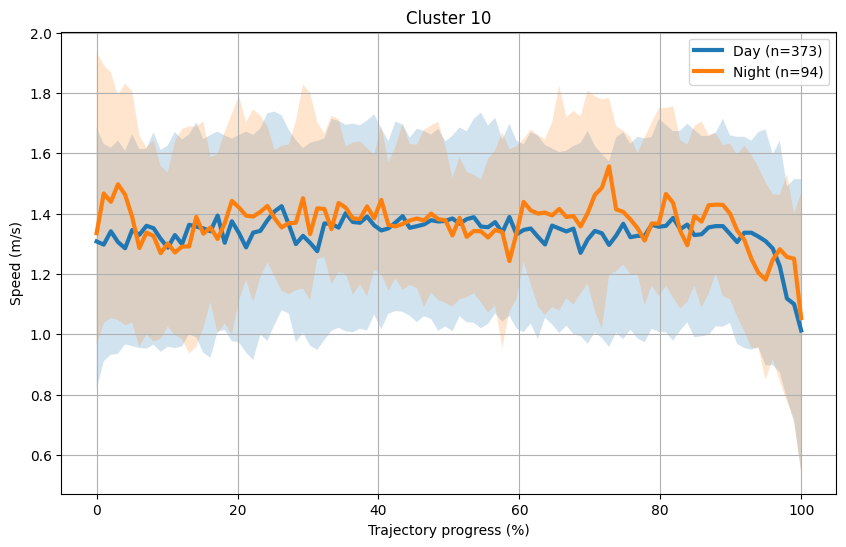

Cluster 6
Day=285  Night=4


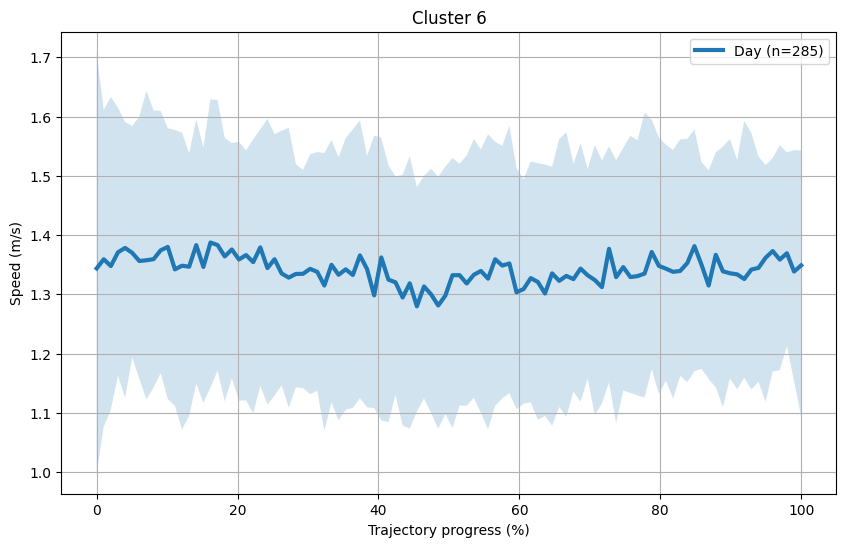

Cluster 2
Day=233  Night=0


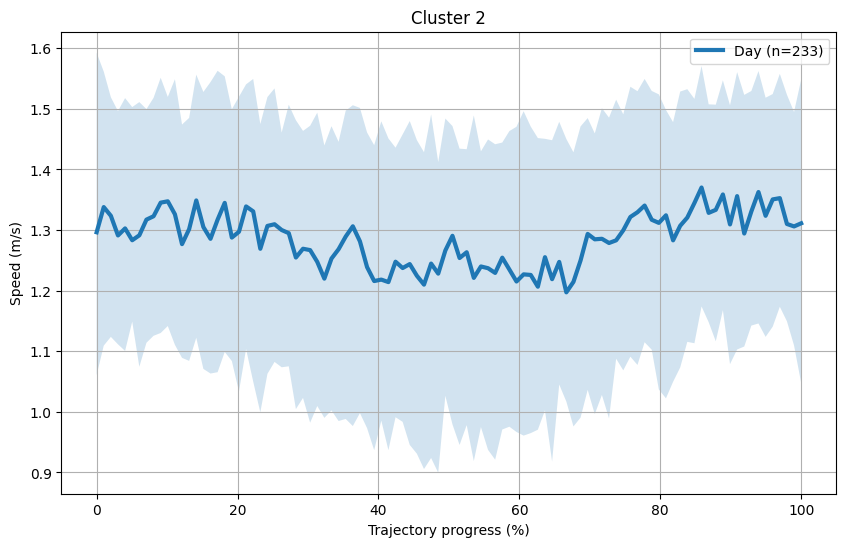

Cluster 7
Day=190  Night=14


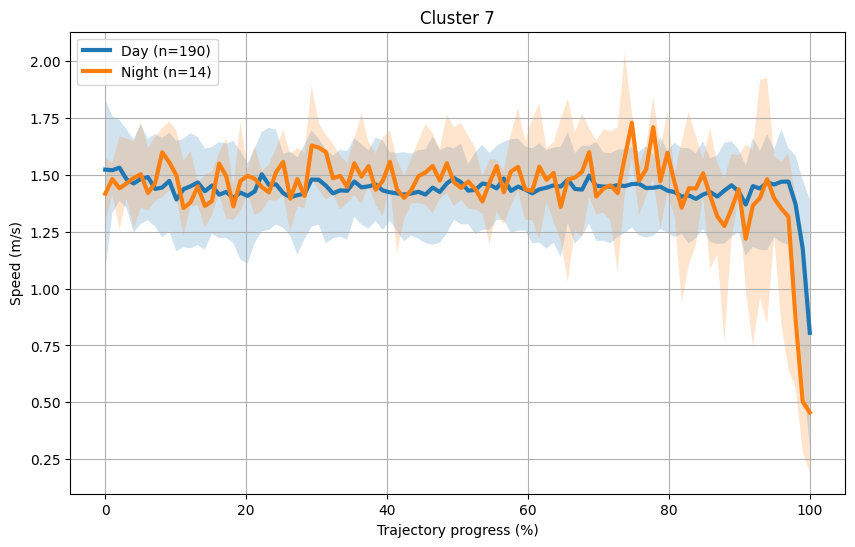

Cluster 22
Day=108  Night=35


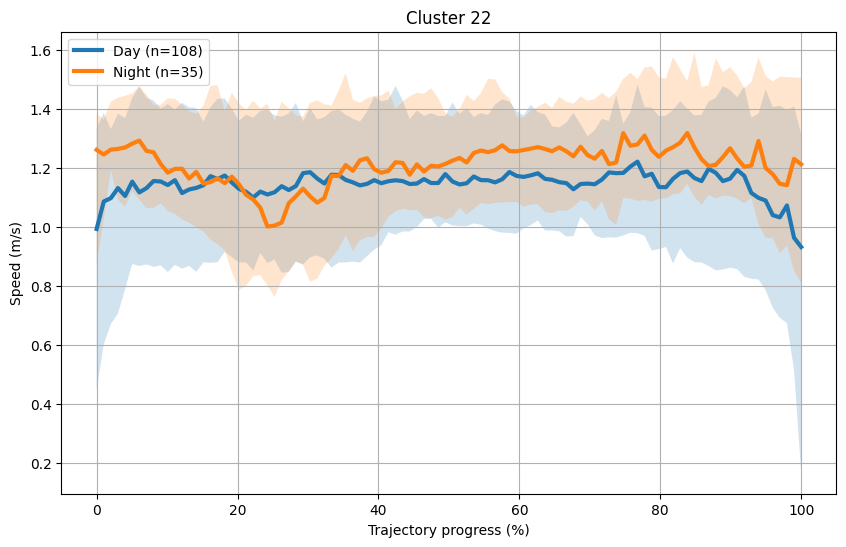

Cluster 0
Day=106  Night=23


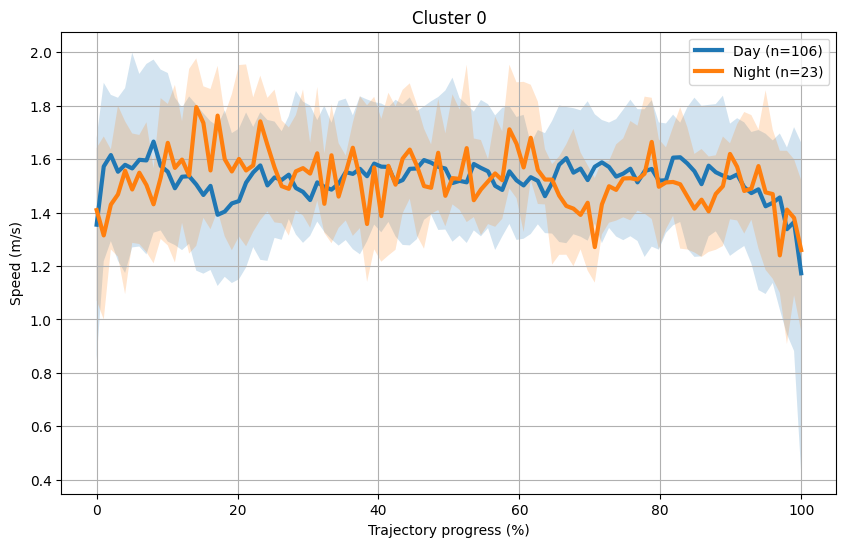

In [66]:
from collections import Counter
from geopy.distance import geodesic
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(0, 1, 100)

top_clusters = [
    c for c,_ in
    Counter(labels[labels != -1]).most_common(6)
]

for cluster_id in top_clusters:

    print(f"Cluster {cluster_id}")

    idxs = np.where(labels == cluster_id)[0]

    profiles_day = []
    profiles_night = []

    for idx in idxs:

        traj = raw_trajectories[idx]

        period = trajectory_period(traj)

        speeds = []
        cumdist = [0]

        for i in range(1, len(traj)):

            p1 = traj[i-1]
            p2 = traj[i]

            d = geodesic(
                (p1["lat"], p1["lon"]),
                (p2["lat"], p2["lon"])
            ).meters

            dt = (
                p2["datetime"]
                - p1["datetime"]
            ).total_seconds()

            if dt <= 0:
                continue

            v = d / dt

            if v > 3:
                continue

            speeds.append(v)

            cumdist.append(
                cumdist[-1] + d
            )

        if len(speeds) < 10:
            continue

        cumdist = np.array(cumdist[:-1])

        if cumdist[-1] == 0:
            continue

        profile = np.interp(
            grid,
            cumdist / cumdist[-1],
            speeds
        )

        if period == "day":
            profiles_day.append(profile)

        elif period == "night":
            profiles_night.append(profile)

    print(
        f"Day={len(profiles_day)}  "
        f"Night={len(profiles_night)}"
    )

    plt.figure(figsize=(10,6))

    for name, profs in [
        ("Day", profiles_day),
        ("Night", profiles_night)
    ]:

        if len(profs) < 5:
            continue

        profs = np.vstack(profs)

        median = np.nanmedian(
            profs,
            axis=0
        )

        q25 = np.nanpercentile(
            profs,
            25,
            axis=0
        )

        q75 = np.nanpercentile(
            profs,
            75,
            axis=0
        )

        plt.plot(
            grid * 100,
            median,
            linewidth=3,
            label=f"{name} (n={len(profs)})"
        )

        plt.fill_between(
            grid * 100,
            q25,
            q75,
            alpha=0.2
        )

    plt.title(
        f"Cluster {cluster_id}"
    )

    plt.xlabel(
        "Trajectory progress (%)"
    )

    plt.ylabel(
        "Speed (m/s)"
    )

    plt.grid(True)

    plt.legend()

    plt.show()